In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
!pip install dagshub
!pip install mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 6.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: dacite
    Found existing installation: dacite 1.9.2
    Uninstalling dacite-1.9.2:
      Successfully uninstalled dacite-1.9.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.1 requires dacite<2,>=1.9, but you have dacite 1.6.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━

In [3]:
import dagshub
import mlflow
dagshub.init(repo_owner='ndoda23', repo_name='MachineLearning---IEEE-CIS-Fraud-Detection', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=3d5885d3-2b50-4158-a87b-eb7d6fce5281&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=9de80eeef557df50dc291e1b5ad765ee7c141957d8805e379866cb107d5072df




Accessing as ndoda23

Initialized MLflow to track repo "ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection"

Repository ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection initialized!

# CLEANING

In [4]:
train_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_identity    = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

train = train_transaction.merge(train_identity, on='TransactionID', how='left')

print("Train shape:", train.shape)
train.head()

Train shape: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [5]:
def optimize_memory(df):
    before = df.memory_usage().sum() / 1024**2
    print(f'მეხსიერება დამუშავებამდე: {before:.2f} MB')
    
    for col in df.columns:
        dtype = df[col].dtype
        
        if dtype == 'object':
            df[col] = df[col].astype('category')
            continue
            
        col_min = df[col].min()
        col_max = df[col].max()
        
        if np.issubdtype(dtype, np.integer):
            if col_min > np.iinfo(np.int8).min and col_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif col_min > np.iinfo(np.int16).min and col_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif col_min > np.iinfo(np.int32).min and col_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
                
        elif np.issubdtype(dtype, np.floating):
            if col_min > np.finfo(np.float32).min and col_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
    
    after = df.memory_usage().sum() / 1024**2
    print(f'მეხსიერება დამუშავების შემდეგ: {after:.2f} MB')
    print(f'შემცირდა: {100 * (before - after) / before:.1f}%')
    
    return df

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

X = train.drop(columns=['isFraud', 'TransactionID'])
y = train['isFraud'].astype('int8')

X = optimize_memory(X)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

მეხსიერება დამუშავებამდე: 1946.36 MB
მეხსიერება დამუშავების შემდეგ: 921.47 MB
შემცირდა: 52.7%
X_train shape: (472432, 432)
X_val shape: (118108, 432)


In [7]:
# Class balance

print(train['isFraud'].value_counts())
print(train['isFraud'].value_counts(normalize=True).round(4))

isFraud
0    569877
1     20663
Name: count, dtype: int64
isFraud
0    0.965
1    0.035
Name: proportion, dtype: float64


In [8]:

print("Missing Values (top 20)")
missing = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
print(missing.head(20))

print("row types")
print(train.dtypes.value_counts())

print("constant rows")
constant = [col for col in train.columns if train[col].nunique() <= 1]
print(f" {len(constant)}")

print("duplicate rows")
print(train.duplicated().sum())

Missing Values (top 20)
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_22    99.124699
id_27    99.124699
id_23    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
D8       87.312290
dtype: float64
row types
float64    399
object      31
int64        4
Name: count, dtype: int64
constant rows
 0
duplicate rows
0


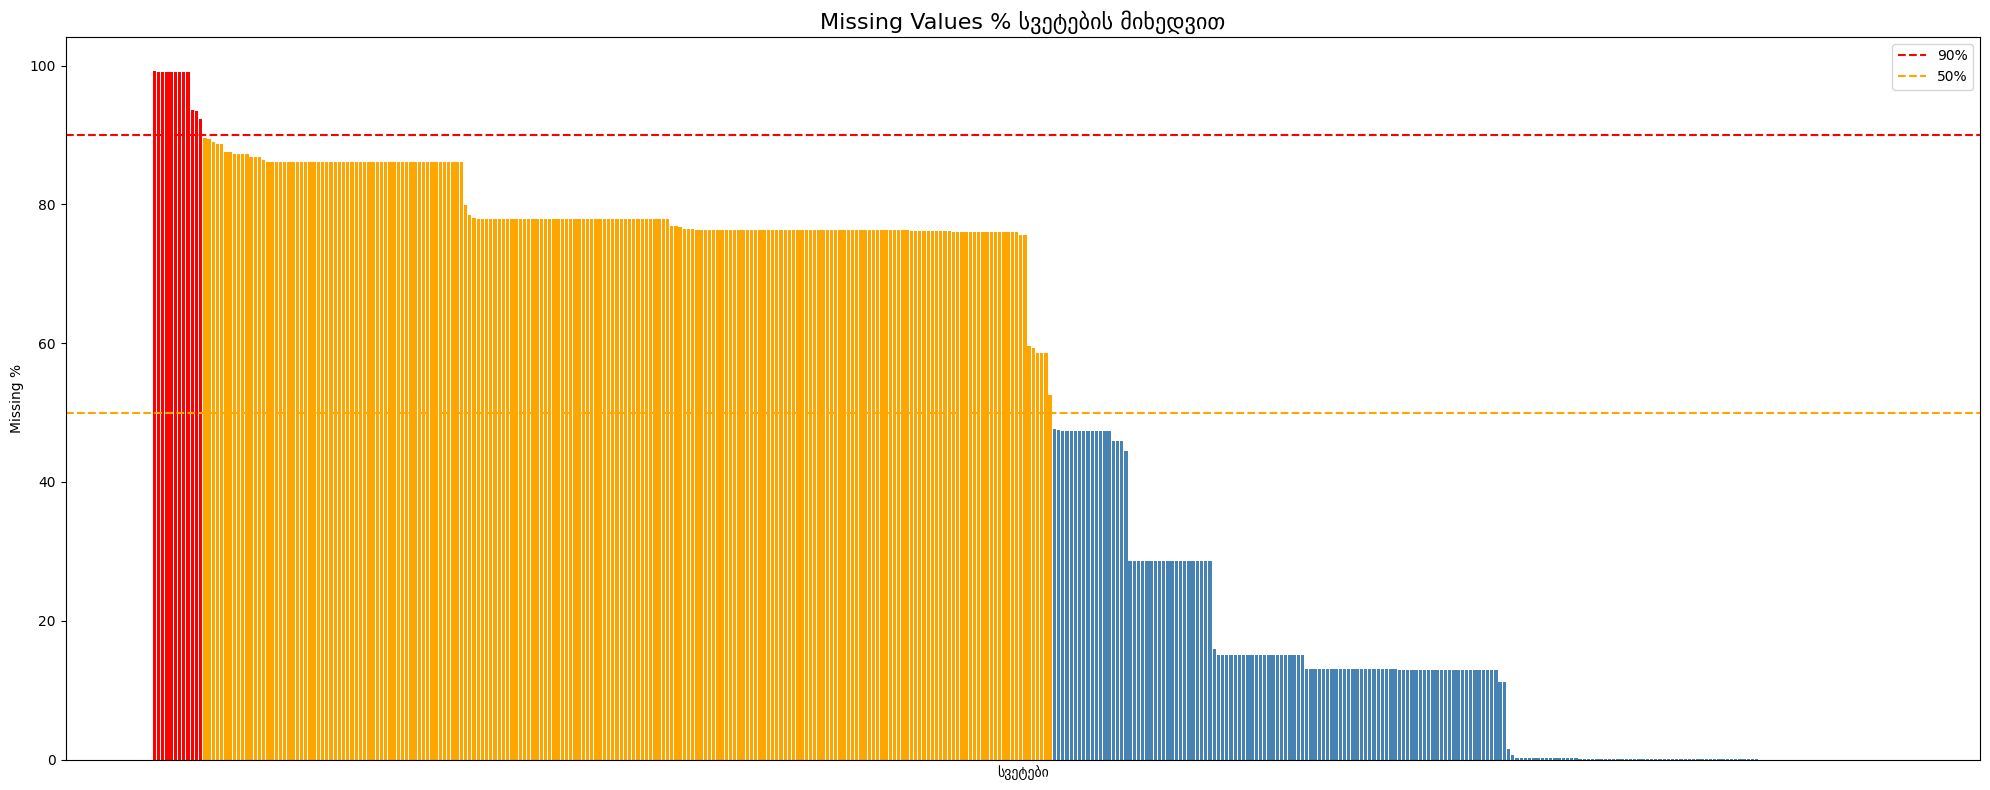

🔴 90%+ ცარიელი სვეტები: 12
🟠 50-90% ცარიელი სვეტები: 202
🔵 0-50% ცარიელი სვეტები: 200


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===== 1. Missing Values Bar Chart =====
missing = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(20, 8))
bars = plt.bar(range(len(missing)), missing.values, color=['red' if x > 90 else 'orange' if x > 50 else 'steelblue' for x in missing.values])

plt.axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='90%')
plt.axhline(y=50, color='orange', linestyle='--', linewidth=1.5, label='50%')

plt.title('Missing Values % სვეტების მიხედვით', fontsize=16)
plt.xlabel('სვეტები')
plt.ylabel('Missing %')
plt.legend()
plt.xticks([]) 
plt.tight_layout()
plt.show()

print(f"🔴 90%+ ცარიელი სვეტები: {(missing > 90).sum()}")
print(f"🟠 50-90% ცარიელი სვეტები: {((missing > 50) & (missing <= 90)).sum()}")
print(f"🔵 0-50% ცარიელი სვეტები: {(missing <= 50).sum()}")

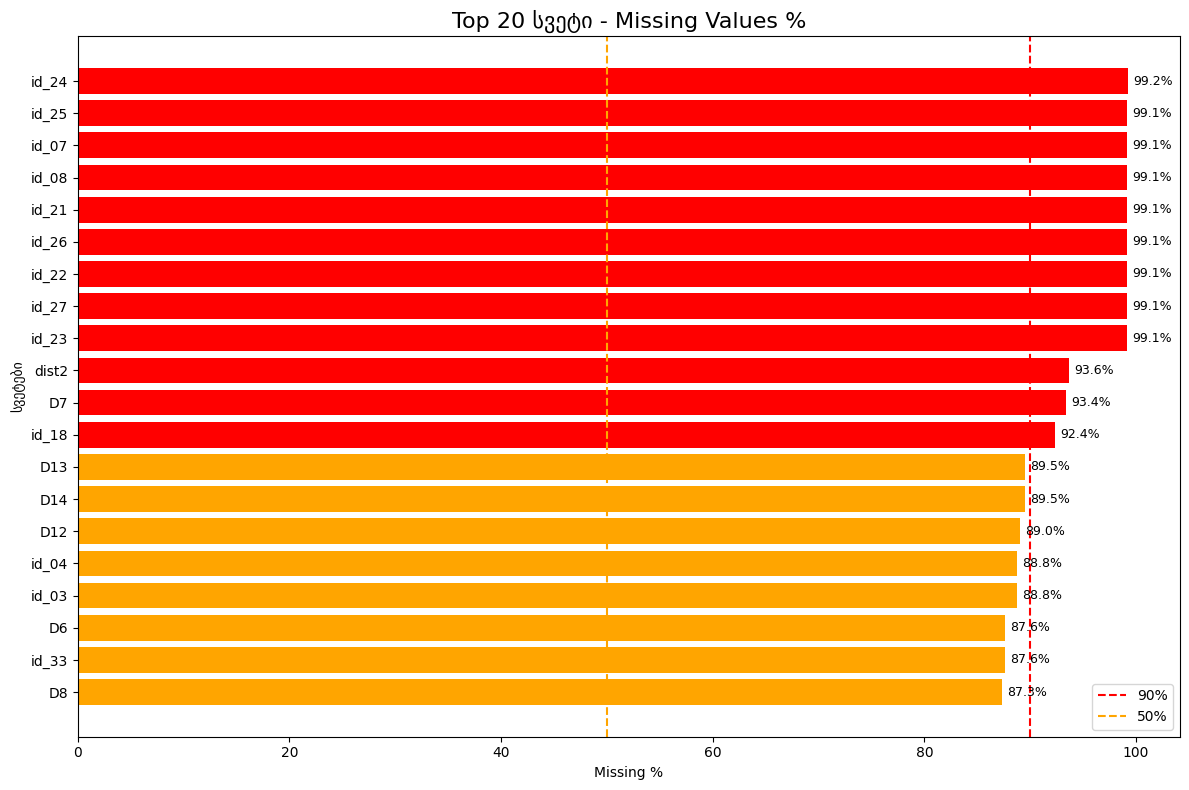

In [10]:
plt.figure(figsize=(12, 8))

top20_missing = missing.head(20)

colors = ['red' if x > 90 else 'orange' if x > 50 else 'steelblue' for x in top20_missing.values]

bars = plt.barh(range(len(top20_missing)), top20_missing.values, color=colors)

plt.axvline(x=90, color='red', linestyle='--', linewidth=1.5, label='90%')
plt.axvline(x=50, color='orange', linestyle='--', linewidth=1.5, label='50%')

plt.yticks(range(len(top20_missing)), top20_missing.index)

for i, (val, bar) in enumerate(zip(top20_missing.values, bars)):
    plt.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)

plt.title('Top 20 სვეტი - Missing Values %', fontsize=16)
plt.xlabel('Missing %')
plt.ylabel('სვეტები')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
from sklearn.base import BaseEstimator, TransformerMixin

class DropHighMissingFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.features_to_drop_ = []
    
    def fit(self, X, y=None):
        nan_ratio = X.isnull().mean()
        self.features_to_drop_ = nan_ratio[nan_ratio > self.threshold].index.tolist()
        print(f"Threshold {self.threshold*100:.0f}%: {len(self.features_to_drop_)} სვეტი წაიშლება")
        print(f"დარჩენილი სვეტები: {X.shape[1] - len(self.features_to_drop_)}")
        return self
    
    def transform(self, X):
        return X.drop(columns=self.features_to_drop_, errors='ignore')

In [12]:
X = train.drop(columns=['isFraud', 'TransactionID'])
y = train['isFraud'].astype('int8')

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cleaner_90 = DropHighMissingFeatures(threshold=0.9)
cleaner_90.fit(X_train)

cleaner_80 = DropHighMissingFeatures(threshold=0.8)
cleaner_80.fit(X_train)

cleaner_50 = DropHighMissingFeatures(threshold=0.5)
cleaner_50.fit(X_train)

Threshold 90%: 12 სვეტი წაიშლება
დარჩენილი სვეტები: 420
Threshold 80%: 74 სვეტი წაიშლება
დარჩენილი სვეტები: 358
Threshold 50%: 214 სვეტი წაიშლება
დარჩენილი სვეტები: 218


DropHighMissingFeatures(threshold=0.5)

# FEATURE ENGINEERING

In [13]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.frequency_maps = {}
    
    def fit(self, X, y=None):
        cat_cols = X.select_dtypes(include=['object', 'category']).columns
        
        for col in cat_cols:
            self.frequency_maps[col] = X[col].value_counts(normalize=True).to_dict()
            
        return self
    
    def transform(self, X):
        X = X.copy()
        
        for col, freq_map in self.frequency_maps.items():
            if col in X.columns:
                X[col] = X[col].map(freq_map).fillna(0)
                
        return X

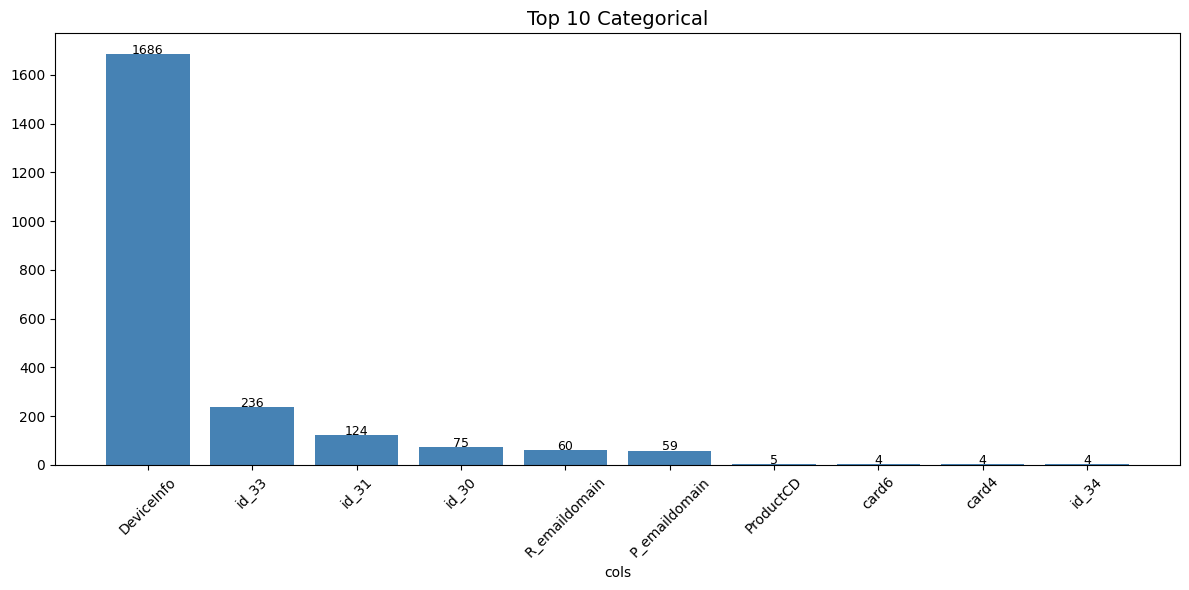

In [14]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
unique_counts = X_train[cat_cols].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(unique_counts.index, unique_counts.values, color='steelblue')
for bar, val in zip(bars, unique_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(val), ha='center', fontsize=9)
plt.title('Top 10 Categorical', fontsize=14)
plt.xlabel('cols')
plt.ylabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

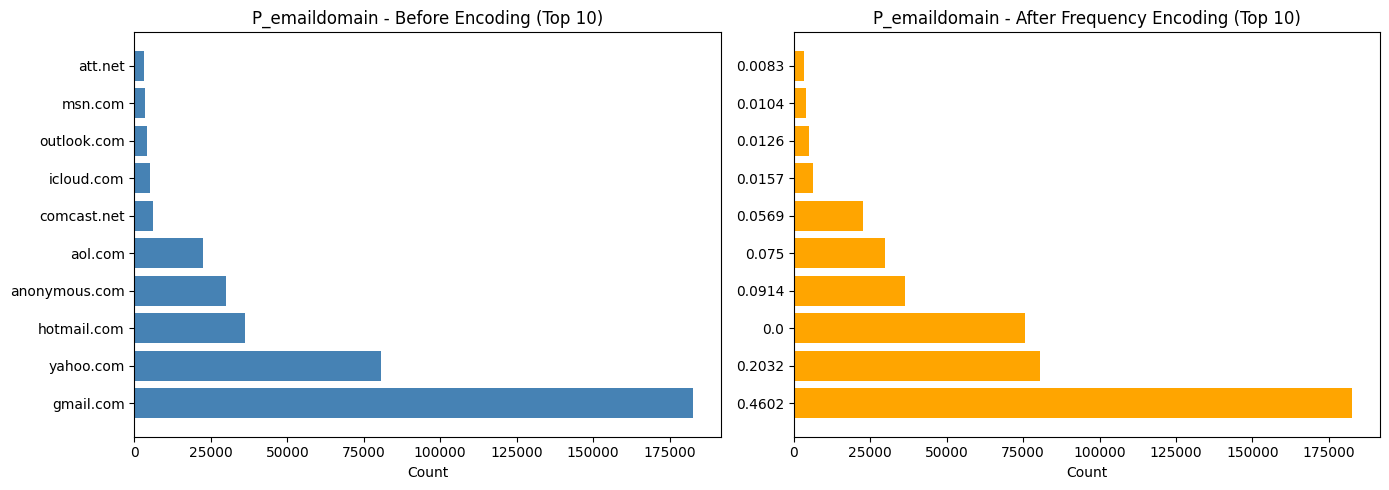

In [15]:
encoder = FrequencyEncoder()
encoder.fit(X_train)
X_train_encoded = encoder.transform(X_train)

col = 'P_emaildomain'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
top_vals = X_train[col].value_counts().head(10)
axes[0].barh(top_vals.index, top_vals.values, color='steelblue')
axes[0].set_title(f'{col} - Before Encoding (Top 10)')
axes[0].set_xlabel('Count')

# After
top_encoded = X_train_encoded[col].value_counts().head(10)
axes[1].barh([str(round(x, 4)) for x in top_encoded.index], 
             top_encoded.values, color='orange')
axes[1].set_title(f'{col} - After Frequency Encoding (Top 10)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [16]:
class MissingValueImputer(BaseEstimator, TransformerMixin):
    def __init__(self, strategy='median'):
        self.strategy = strategy
        self.fill_values = {}
    
    def fit(self, X, y=None):
        if self.strategy == 'minus999':
            return self
            
        num_cols = X.select_dtypes(include=['float32', 'float64', 
                                            'int8', 'int16', 'int32', 'int64']).columns
        
        for col in num_cols:
            self.fill_values[col] = X[col].median()
            
        return self
    
    def transform(self, X):
        X = X.copy()
        
        if self.strategy == 'minus999':
            num_cols = X.select_dtypes(include=['float32', 'float64',
                                                'int8', 'int16', 'int32', 'int64']).columns
            X[num_cols] = X[num_cols].fillna(-999)
            return X
        
        for col, val in self.fill_values.items():
            if col in X.columns:
                X[col] = X[col].fillna(val)
                
        return X

In [17]:
cleaner = DropHighMissingFeatures(threshold=0.9)
cleaner.fit(X_train)
X_cleaned = cleaner.transform(X_train)

encoder = FrequencyEncoder()
encoder.fit(X_cleaned)
X_encoded = encoder.transform(X_cleaned)

imputer = MissingValueImputer(strategy='median')
imputer.fit(X_encoded)
X_imputed = imputer.transform(X_encoded)

print("დარჩენილი Missing Values:", X_imputed.isnull().sum().sum())

Threshold 90%: 12 სვეტი წაიშლება
დარჩენილი სვეტები: 420
დარჩენილი Missing Values: 0


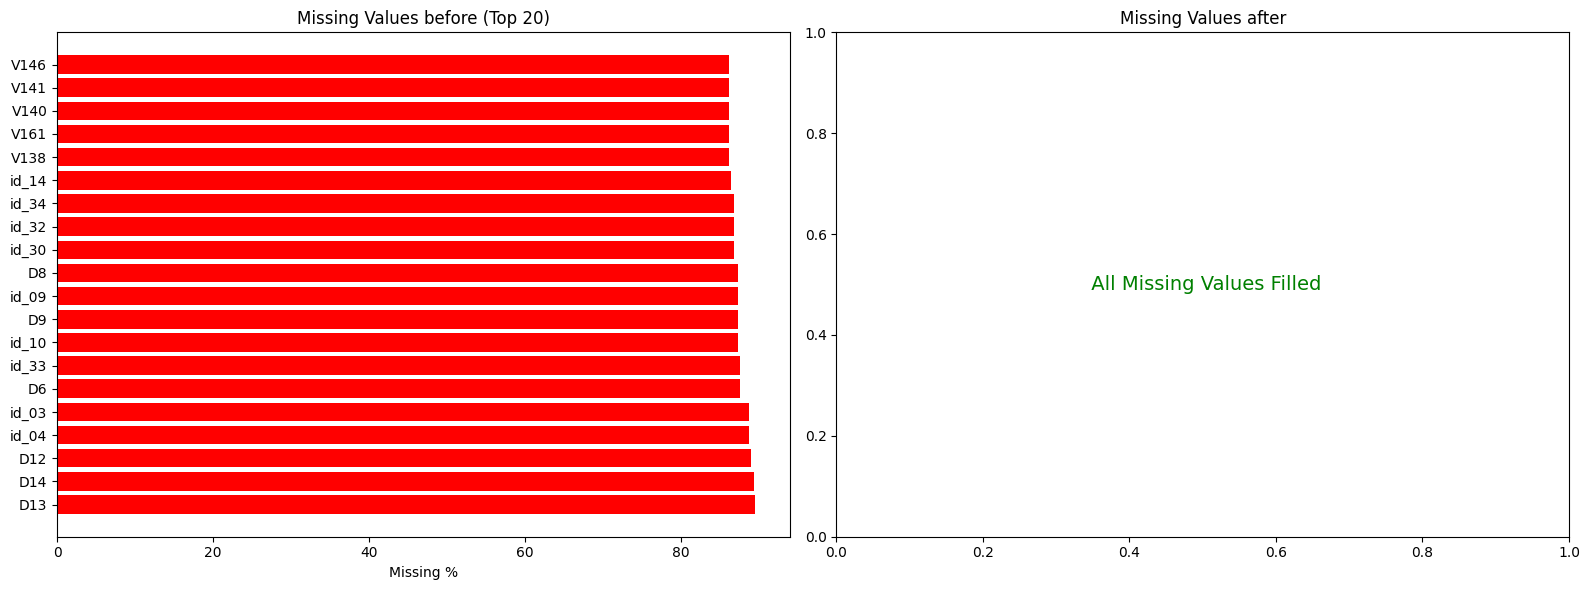

In [18]:
missing_before = (X_cleaned.isnull().sum() / len(X_cleaned) * 100)
missing_before = missing_before[missing_before > 0].sort_values(ascending=False).head(20)

missing_after = (X_imputed.isnull().sum() / len(X_imputed) * 100)
missing_after = missing_after[missing_after > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(missing_before.index, missing_before.values, color='red')
axes[0].set_title('Missing Values before (Top 20)', fontsize=12)
axes[0].set_xlabel('Missing %')

if len(missing_after) == 0:
    axes[1].text(0.5, 0.5, ' All Missing Values Filled', 
                ha='center', va='center', fontsize=14, color='green')
    axes[1].set_title('Missing Values after', fontsize=12)
else:
    axes[1].barh(missing_after.index, missing_after.values, color='green')
    axes[1].set_title('Missing Values after', fontsize=12)
    axes[1].set_xlabel('Missing %')

plt.tight_layout()
plt.show()

In [19]:
 class TimeFeatureExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X['hour'] = (X['TransactionDT'] // 3600) % 24
        X['day_of_week'] = (X['TransactionDT'] // (3600 * 24)) % 7
        X['is_weekend'] = (X['day_of_week'] >= 5).astype('int8')
        X['is_night'] = ((X['hour'] >= 22) | (X['hour'] <= 6)).astype('int8')
        return X

In [20]:
class TransactionAmtTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X['amt_log'] = np.log1p(X['TransactionAmt'])
        X['amt_rounded'] = (X['TransactionAmt'] % 1 == 0).astype('int8')
        X['amt_cents'] = X['TransactionAmt'] % 1
        return X

In [21]:
class GroupAggregator(BaseEstimator, TransformerMixin):
    def __init__(self, group_cols=['card1', 'addr1']):
        self.group_cols = group_cols
        self.stats = {}
    
    def fit(self, X, y=None):
        for col in self.group_cols:
            if col in X.columns:
                self.stats[col] = X.groupby(col)['TransactionAmt'].agg(['mean', 'std']).to_dict()
        return self
    
    def transform(self, X):
        X = X.copy()
        for col in self.group_cols:
            if col in X.columns:
                X[f'{col}_amt_mean'] = X[col].map(self.stats[col]['mean'])
                X[f'{col}_amt_std'] = X[col].map(self.stats[col]['std'])
                X[f'{col}_amt_diff'] = X['TransactionAmt'] - X[col].map(self.stats[col]['mean'])
        return X

In [22]:
time_extractor = TimeFeatureExtractor()
amt_transformer = TransactionAmtTransformer()
group_aggregator = GroupAggregator()

X_featured = time_extractor.transform(X_imputed)
X_featured = amt_transformer.transform(X_featured)
group_aggregator.fit(X_featured)
X_featured = group_aggregator.transform(X_featured)

print(f"სვეტები Feature Engineering-მდე: {X_imputed.shape[1]}")
print(f"სვეტები Feature Engineering-ის შემდეგ: {X_featured.shape[1]}")
print(f"დამატებული სვეტები: {X_featured.shape[1] - X_imputed.shape[1]}")
print(f"\nახალი სვეტები:")
new_cols = set(X_featured.columns) - set(X_imputed.columns)
print(list(new_cols))

სვეტები Feature Engineering-მდე: 420
სვეტები Feature Engineering-ის შემდეგ: 433
დამატებული სვეტები: 13

ახალი სვეტები:
['addr1_amt_diff', 'card1_amt_diff', 'is_weekend', 'day_of_week', 'card1_amt_mean', 'amt_cents', 'hour', 'amt_rounded', 'addr1_amt_std', 'amt_log', 'is_night', 'addr1_amt_mean', 'card1_amt_std']


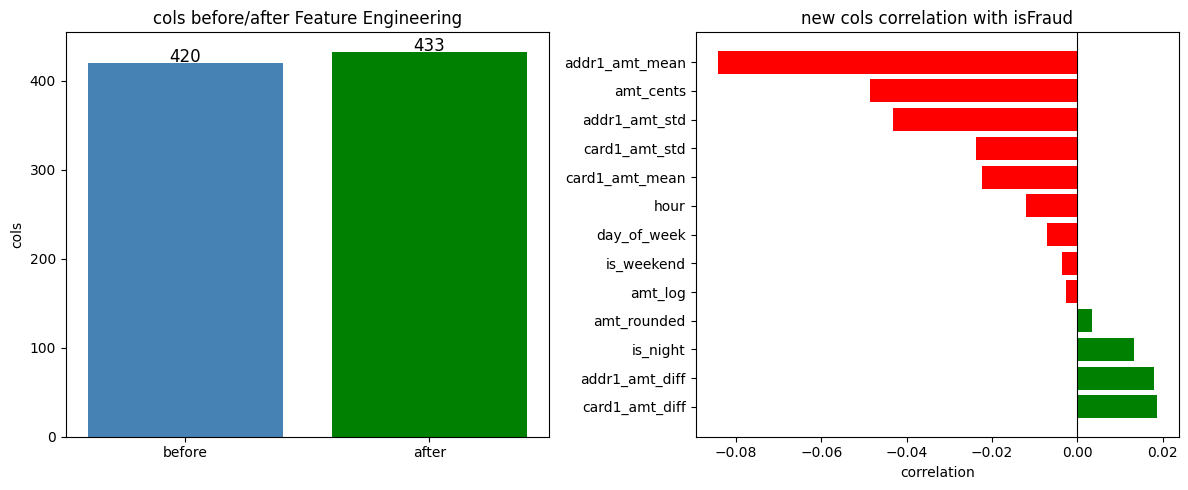

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['before', 'after'], [X_imputed.shape[1], X_featured.shape[1]], 
            color=['steelblue', 'green'])
axes[0].set_title('cols before/after Feature Engineering')
axes[0].set_ylabel('cols')
for i, v in enumerate([X_imputed.shape[1], X_featured.shape[1]]):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=12)

new_cols = list(set(X_featured.columns) - set(X_imputed.columns))
temp = X_featured[new_cols].copy()
temp['isFraud'] = y_train.values

correlations = temp.corr()['isFraud'].drop('isFraud').sort_values(ascending=False)

axes[1].barh(correlations.index, correlations.values, 
             color=['green' if x > 0 else 'red' for x in correlations.values])
axes[1].set_title('new cols correlation with isFraud')
axes[1].set_xlabel('correlation')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# FEATURE SELECTION

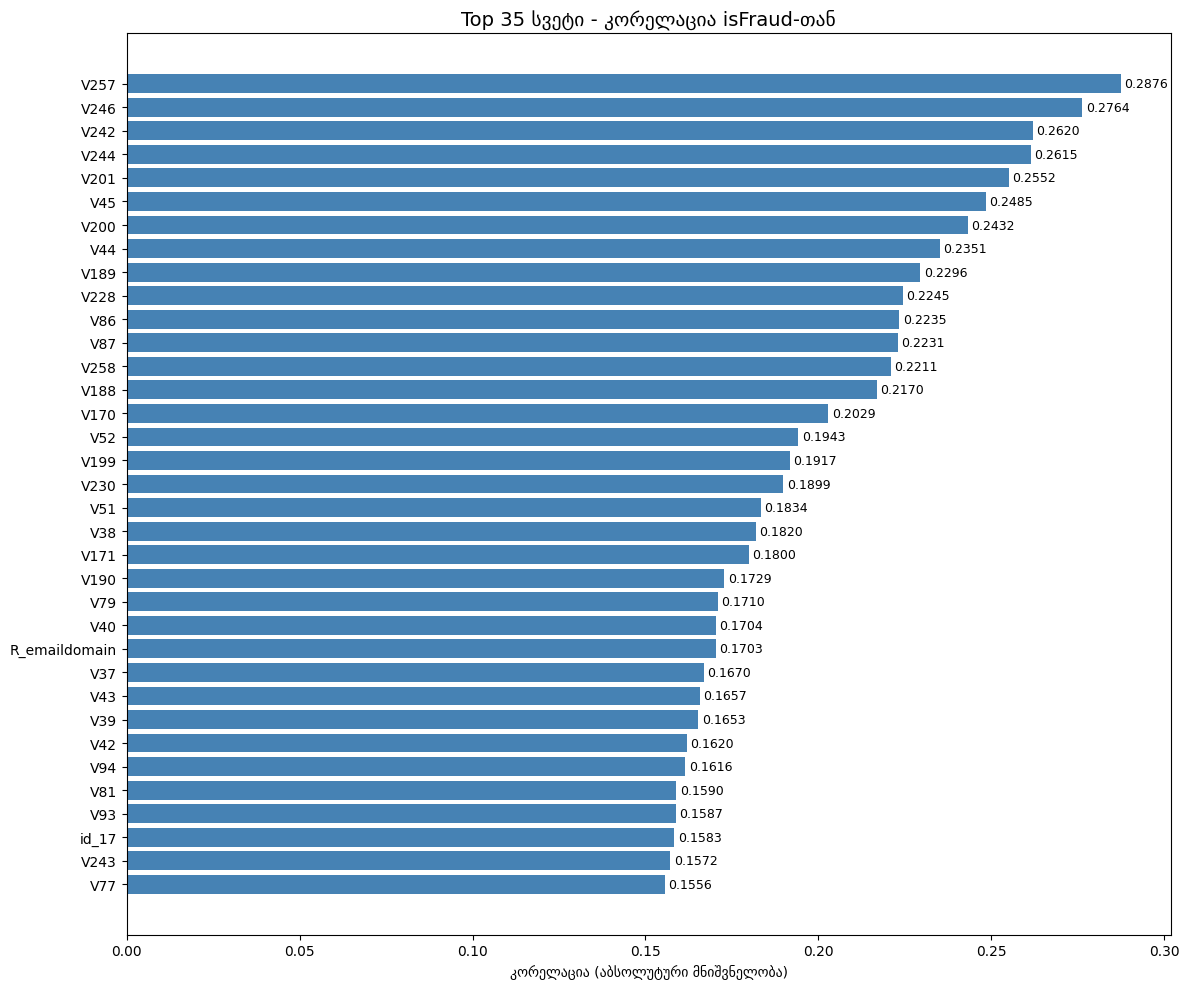

In [24]:
sample_idx = X_featured.sample(50000, random_state=42).index

temp = X_featured.loc[sample_idx].select_dtypes(include=['float32', 'float64', 
                                                          'int8', 'int16', 'int32', 'int64']).copy()
temp['isFraud'] = y_train.loc[sample_idx].values

correlations = temp.corr()['isFraud'].drop('isFraud')
correlations = correlations.abs().sort_values(ascending=False).head(35)

plt.figure(figsize=(12, 10))
bars = plt.barh(correlations.index, correlations.values, color='steelblue')
for bar, val in zip(bars, correlations.values):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}', va='center', fontsize=9)

plt.title('Top 35 სვეტი - კორელაცია isFraud-თან', fontsize=14)
plt.xlabel('კორელაცია (აბსოლუტური მნიშვნელობა)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

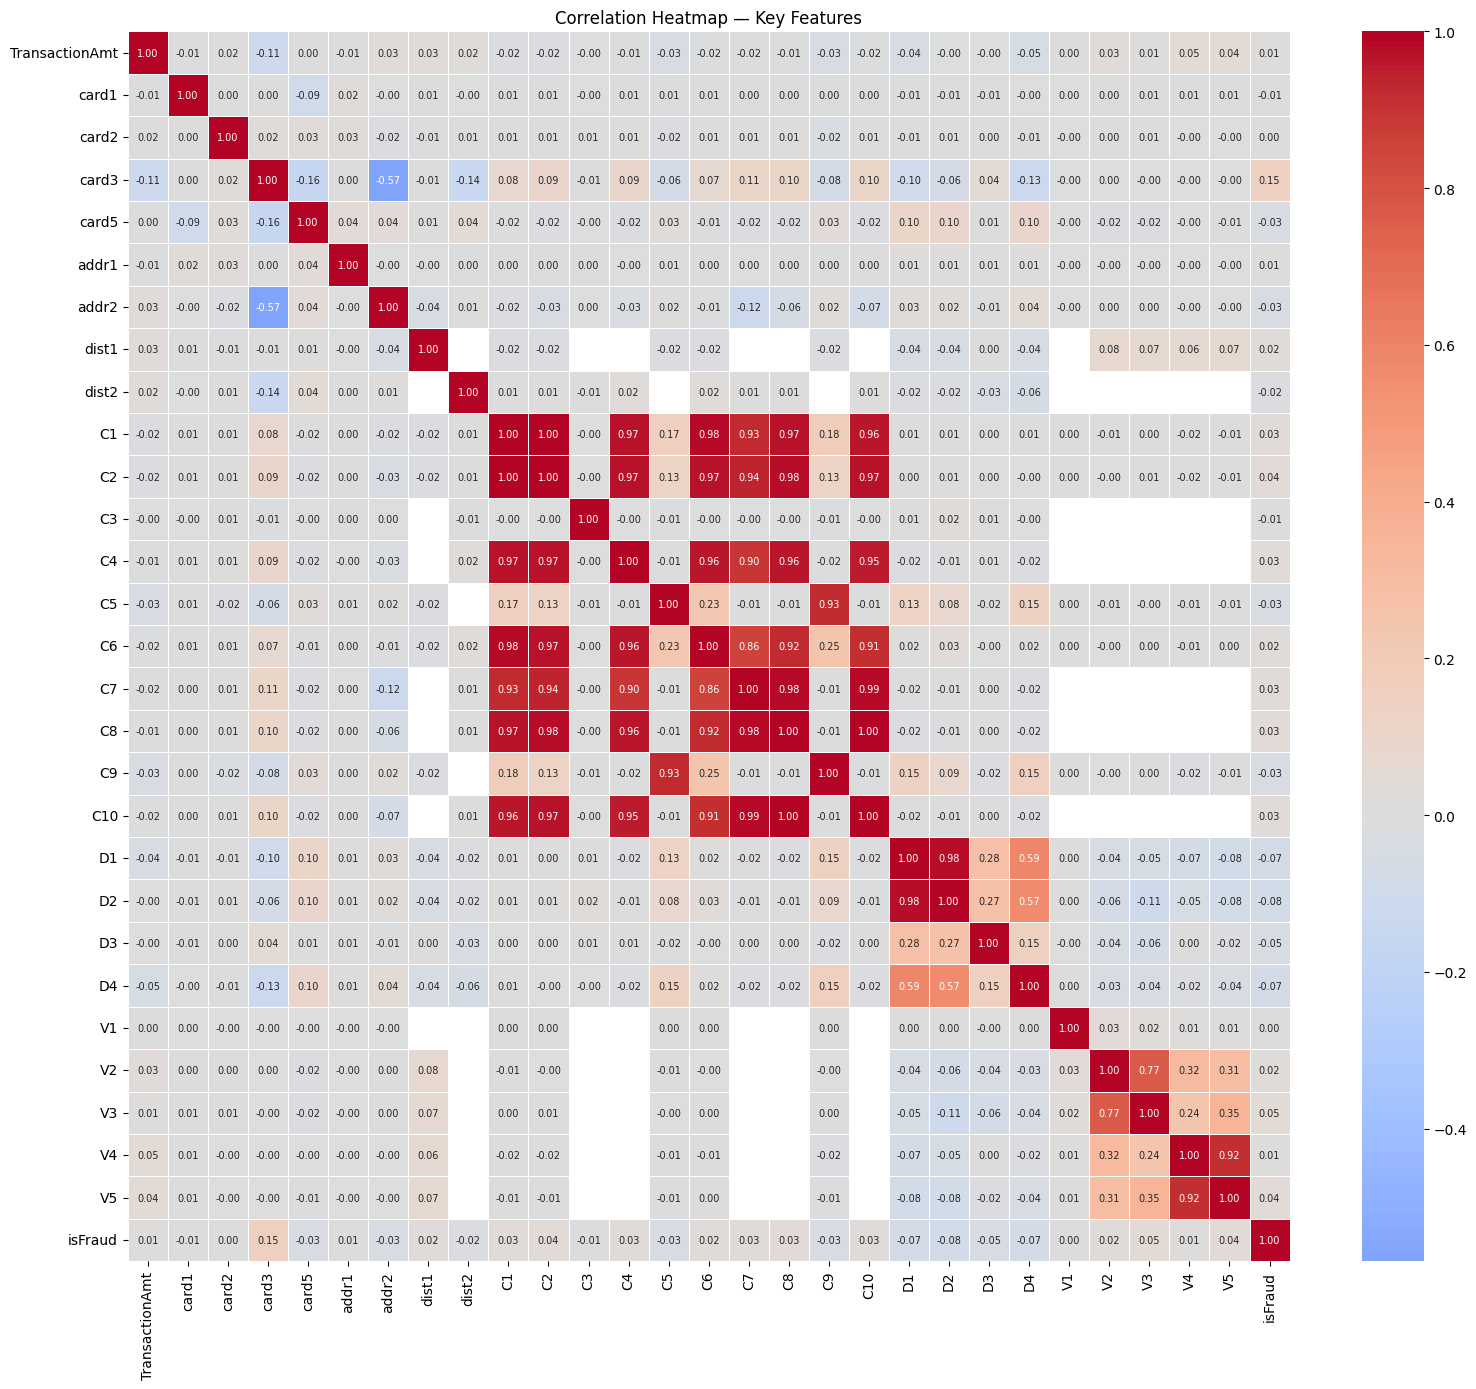

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

key_cols = [
    'TransactionAmt', 'card1', 'card2', 'card3', 'card5',
    'addr1', 'addr2', 'dist1', 'dist2',
    'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10',
    'D1', 'D2', 'D3', 'D4',
    'V1', 'V2', 'V3', 'V4', 'V5',
    'isFraud'
]

existing_cols = [c for c in key_cols if c in train.columns]
corr_matrix = train[existing_cols].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Correlation Heatmap — Key Features')
plt.tight_layout()
plt.show()

In [26]:
print(X_featured.shape)
print(y_train.shape)

(472432, 433)
(472432,)


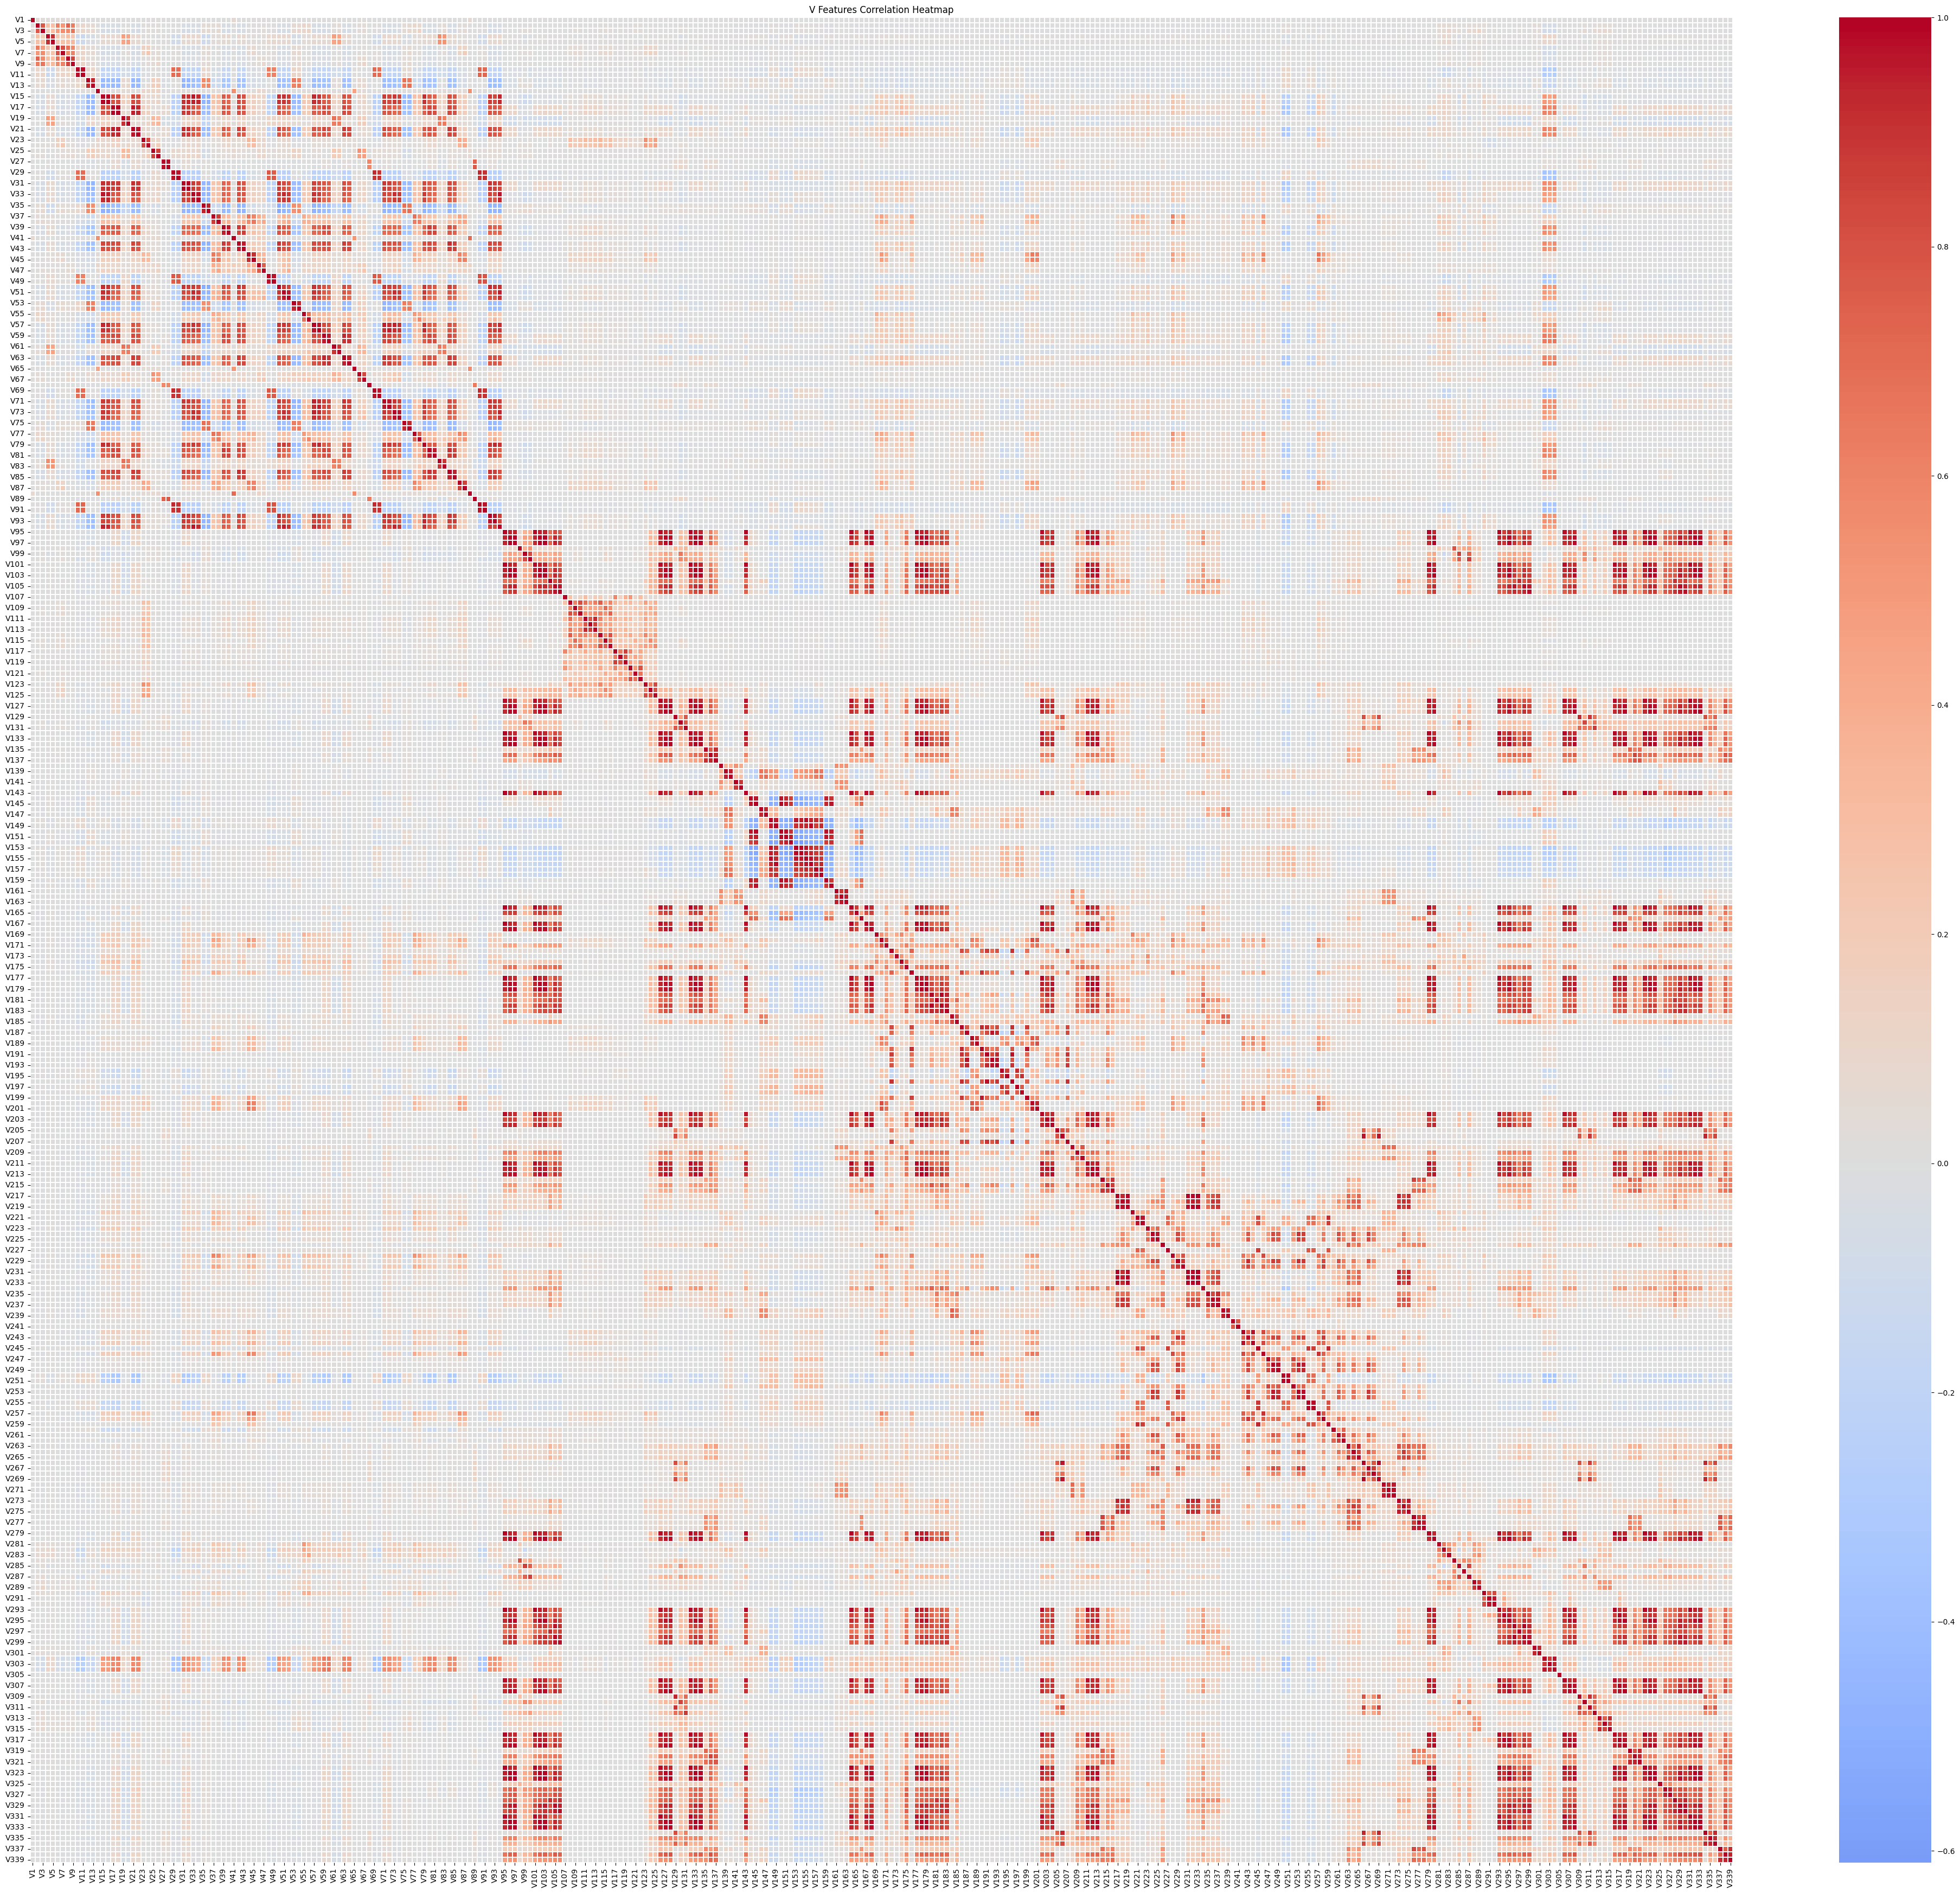

In [27]:
v_cols = [col for col in X_imputed.columns if col.startswith('V')]

corr_v = X_imputed[v_cols].corr()

plt.figure(figsize=(40, 35))
sns.heatmap(
    corr_v,
    cmap='coolwarm', center=0,
    linewidths=0.3,
    annot=False 
)
plt.title('V Features Correlation Heatmap')
plt.tight_layout()
plt.show()

In [28]:
print(X_featured.shape)
print(y_train.shape)

(472432, 433)
(472432,)


In [29]:
class DropCorrelatedFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.92, cols_prefix=None):
        self.threshold = threshold
        self.cols_prefix = cols_prefix
        self.features_to_drop_ = []
    
    def fit(self, X, y=None):
        if self.cols_prefix:
            check_cols = [c for c in X.columns if c.startswith(self.cols_prefix)]
        else:
            check_cols = X.columns.tolist()
            
        corr_matrix = X[check_cols].corr().abs()
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        self.features_to_drop_ = [
            col for col in upper.columns if any(upper[col] > self.threshold)
        ]
        print(f"Threshold {self.threshold}: წაიშლება {len(self.features_to_drop_)}")
        print(f"დარჩება {X.shape[1] - len(self.features_to_drop_)} სვეტი")
        return self
    
    def transform(self, X):
        return X.drop(columns=self.features_to_drop_, errors='ignore')

# TRAINING AND MLFLOW LOGS

In [30]:
import mlflow
import mlflow.sklearn
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import dagshub

dagshub.init(repo_owner='ndoda23', 
             repo_name='MachineLearning---IEEE-CIS-Fraud-Detection', 
             mlflow=True)

mlflow.set_experiment("XGBoost_Training")

Initialized MLflow to track repo "ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection"

Repository ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection initialized!

<Experiment: artifact_location='mlflow-artifacts:/5bbfa84ff4cc43fcbf3ed18f77bbd4c3', creation_time=1778061264728, experiment_id='0', last_update_time=1778061264728, lifecycle_stage='active', name='XGBoost_Training', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [31]:
# ===== Cleaning Run =====
with mlflow.start_run(run_name="XGBoost_Cleaning"):
    cleaner = DropHighMissingFeatures(threshold=0.9)
    cleaner.fit(X_train)
    
    mlflow.log_param("missing_threshold", 0.9)
    mlflow.log_metric("dropped_columns", len(cleaner.features_to_drop_))
    mlflow.log_metric("remaining_columns", X_train.shape[1] - len(cleaner.features_to_drop_))

Threshold 90%: 12 სვეტი წაიშლება
დარჩენილი სვეტები: 420
🏃 View run XGBoost_Cleaning at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/0cdfcb3596204b1baa91735d31560b86
🧪 View experiment at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [32]:
# ===== Feature Engineering Run =====
with mlflow.start_run(run_name="XGBoost_Feature_Engineering"):
    mlflow.log_param("encoding", "FrequencyEncoding")
    mlflow.log_param("imputer_strategy", "median")
    mlflow.log_param("time_features", True)
    mlflow.log_param("amt_features", True)
    mlflow.log_param("group_aggregations", "card1, addr1")
    mlflow.log_metric("features_added", 13)

🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/208bcc01096f4501a1ec78b88f72b2da
🧪 View experiment at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [35]:
# Run 1 - median, 0.9, 0.92
with mlflow.start_run(run_name="XGBoost_Training_run1"):
    pipeline = Pipeline([
        ('cleaner',  DropHighMissingFeatures(threshold=0.9)),
        ('encoder',  FrequencyEncoder()),
        ('imputer',  MissingValueImputer(strategy='median')),
        ('time',     TimeFeatureExtractor()),
        ('amt',      TransactionAmtTransformer()),
        ('group',    GroupAggregator()),
        ('selector', DropCorrelatedFeatures(threshold=0.92)),
        ('model',    XGBClassifier(n_estimators=300, learning_rate=0.05, 
                                   max_depth=6, random_state=42, 
                                   eval_metric='auc', device='cuda'))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='roc_auc')
    
    mlflow.log_param("missing_threshold", 0.9)
    mlflow.log_param("imputer_strategy", "median")
    mlflow.log_param("corr_threshold", 0.92)
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_metric("val_auc", auc)
    mlflow.log_metric("cv_auc_mean", cv_scores.mean())
    mlflow.log_metric("cv_auc_std", cv_scores.std())
    mlflow.sklearn.log_model(pipeline, "pipeline")
    print(f"Run 1: Val AUC={auc:.4f}, CV AUC={cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Threshold 90%: 12 სვეტი წაიშლება
დარჩენილი სვეტები: 420
Threshold 0.92: წაიშლება 165
დარჩება 268 სვეტი


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [13:29:24] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Threshold 90%: 12 სვეტი წაიშლება
დარჩენილი სვეტები: 420
Threshold 0.92: წაიშლება 163
დარჩება 270 სვეტი
Threshold 90%: 12 სვეტი წაიშლება
დარჩენილი სვეტები: 420
Threshold 0.92: წაიშლება 170
დარჩება 263 სვეტი
Threshold 90%: 12 სვეტი წაიშლება
დარჩენილი სვეტები: 420
Threshold 0.92: წაიშლება 167
დარჩება 266 სვეტი


2026/05/06 13:37:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 13:37:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run 1: Val AUC=0.9310, CV AUC=0.9289 ± 0.0018
🏃 View run XGBoost_Training_run1 at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/122cbeabe712495b9eee1a86a50a4b0c
🧪 View experiment at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [37]:
import mlflow

mlflow.set_experiment(experiment_id="0") 

y_train_proba = pipeline.predict_proba(X_train)[:, 1]
y_train_class = pipeline.predict(X_train)

with mlflow.start_run(run_id="941f906bfb42451cb884f83aba9e08be"):
    mlflow.log_metric("train_roc_auc",  roc_auc_score(y_train, y_train_proba))
    mlflow.log_metric("train_val_diff", roc_auc_score(y_train, y_train_proba) - roc_auc_score(y_val, y_pred))


print("მეტრიკები წარმატებით დაემატა არსებულ Run-ს!")

🏃 View run XGBoost_Training_run1 at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/941f906bfb42451cb884f83aba9e08be
🧪 View experiment at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
მეტრიკები წარმატებით დაემატა არსებულ Run-ს!


In [39]:
# Run 2 - minus999, 0.9, 0.92
with mlflow.start_run(run_name="XGBoost_Training_run2"):
    pipeline = Pipeline([
        ('cleaner',  DropHighMissingFeatures(threshold=0.9)),
        ('encoder',  FrequencyEncoder()),
        ('imputer',  MissingValueImputer(strategy='minus999')),
        ('time',     TimeFeatureExtractor()),
        ('amt',      TransactionAmtTransformer()),
        ('group',    GroupAggregator()),
        ('selector', DropCorrelatedFeatures(threshold=0.92)),
        ('model',    XGBClassifier(n_estimators=300, learning_rate=0.05,
                                   max_depth=6, random_state=42,
                                   eval_metric='auc', device='cuda'))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='roc_auc')
    
    mlflow.log_param("missing_threshold", 0.9)
    mlflow.log_param("imputer_strategy", "minus999")
    mlflow.log_param("corr_threshold", 0.92)
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_metric("val_auc", auc)
    mlflow.log_metric("cv_auc_mean", cv_scores.mean())
    mlflow.log_metric("cv_auc_std", cv_scores.std())
    mlflow.sklearn.log_model(pipeline, "pipeline")
    print(f"Run 2: Val AUC={auc:.4f}, CV AUC={cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Threshold 90%: 12 სვეტი წაიშლება
დარჩენილი სვეტები: 420
Threshold 0.92: წაიშლება 338
დარჩება 95 სვეტი
Threshold 90%: 12 სვეტი წაიშლება
დარჩენილი სვეტები: 420
Threshold 0.92: წაიშლება 337
დარჩება 96 სვეტი
Threshold 90%: 12 სვეტი წაიშლება
დარჩენილი სვეტები: 420
Threshold 0.92: წაიშლება 340
დარჩება 93 სვეტი
Threshold 90%: 12 სვეტი წაიშლება
დარჩენილი სვეტები: 420
Threshold 0.92: წაიშლება 338
დარჩება 95 სვეტი


2026/05/06 13:55:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 13:55:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run 2: Val AUC=0.9355, CV AUC=0.9304 ± 0.0015
🏃 View run XGBoost_Training_run2 at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/f70cd4cc57a346e8836b7d203ce043d5
🧪 View experiment at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [41]:
import mlflow

mlflow.set_experiment(experiment_id="0") 

y_train_proba = pipeline.predict_proba(X_train)[:, 1]
y_train_class = pipeline.predict(X_train)

with mlflow.start_run(run_id="f70cd4cc57a346e8836b7d203ce043d5"):
    mlflow.log_metric("train_roc_auc",  roc_auc_score(y_train, y_train_proba))
    mlflow.log_metric("train_val_diff", roc_auc_score(y_train, y_train_proba) - roc_auc_score(y_val, y_pred))


print("მეტრიკები წარმატებით დაემატა არსებულ Run-ს!")

🏃 View run XGBoost_Training_run2 at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/f70cd4cc57a346e8836b7d203ce043d5
🧪 View experiment at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
მეტრიკები წარმატებით დაემატა არსებულ Run-ს!


In [42]:
# Run 3 - median, 0.8, 0.92
with mlflow.start_run(run_name="XGBoost_Training_run3"):
    pipeline = Pipeline([
        ('cleaner',  DropHighMissingFeatures(threshold=0.8)),
        ('encoder',  FrequencyEncoder()),
        ('imputer',  MissingValueImputer(strategy='median')),
        ('time',     TimeFeatureExtractor()),
        ('amt',      TransactionAmtTransformer()),
        ('group',    GroupAggregator()),
        ('selector', DropCorrelatedFeatures(threshold=0.92)),
        ('model',    XGBClassifier(n_estimators=300, learning_rate=0.05,
                                   max_depth=6, random_state=42,
                                   eval_metric='auc', device='cuda'))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='roc_auc')
    
    mlflow.log_param("missing_threshold", 0.8)
    mlflow.log_param("imputer_strategy", "median")
    mlflow.log_param("corr_threshold", 0.92)
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_metric("val_auc", auc)
    mlflow.log_metric("cv_auc_mean", cv_scores.mean())
    mlflow.log_metric("cv_auc_std", cv_scores.std())
    mlflow.sklearn.log_model(pipeline, "pipeline")
    print(f"Run 3: Val AUC={auc:.4f}, CV AUC={cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Threshold 80%: 74 სვეტი წაიშლება
დარჩენილი სვეტები: 358
Threshold 0.92: წაიშლება 136
დარჩება 235 სვეტი
Threshold 80%: 74 სვეტი წაიშლება
დარჩენილი სვეტები: 358
Threshold 0.92: წაიშლება 134
დარჩება 237 სვეტი
Threshold 80%: 74 სვეტი წაიშლება
დარჩენილი სვეტები: 358
Threshold 0.92: წაიშლება 139
დარჩება 232 სვეტი
Threshold 80%: 74 სვეტი წაიშლება
დარჩენილი სვეტები: 358
Threshold 0.92: წაიშლება 137
დარჩება 234 სვეტი


2026/05/06 14:09:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 14:09:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run 3: Val AUC=0.9306, CV AUC=0.9287 ± 0.0016
🏃 View run XGBoost_Training_run3 at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/35ba3ed0c03545948b2e9124e0436c9e
🧪 View experiment at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [43]:
import mlflow

mlflow.set_experiment(experiment_id="0") 

y_train_proba = pipeline.predict_proba(X_train)[:, 1]
y_train_class = pipeline.predict(X_train)

with mlflow.start_run(run_id="35ba3ed0c03545948b2e9124e0436c9e"):
    mlflow.log_metric("train_roc_auc",  roc_auc_score(y_train, y_train_proba))
    mlflow.log_metric("train_val_diff", roc_auc_score(y_train, y_train_proba) - roc_auc_score(y_val, y_pred))


print("მეტრიკები წარმატებით დაემატა არსებულ Run-ს!")

🏃 View run XGBoost_Training_run3 at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/35ba3ed0c03545948b2e9124e0436c9e
🧪 View experiment at: https://dagshub.com/ndoda23/MachineLearning---IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
მეტრიკები წარმატებით დაემატა არსებულ Run-ს!


In [ ]:
# Run 4 - median, 0.9, 0.95
with mlflow.start_run(run_name="XGBoost_Training_run4"):
    pipeline = Pipeline([
        ('cleaner',  DropHighMissingFeatures(threshold=0.9)),
        ('encoder',  FrequencyEncoder()),
        ('imputer',  MissingValueImputer(strategy='median')),
        ('time',     TimeFeatureExtractor()),
        ('amt',      TransactionAmtTransformer()),
        ('group',    GroupAggregator()),
        ('selector', DropCorrelatedFeatures(threshold=0.95)),
        ('model',    XGBClassifier(n_estimators=300, learning_rate=0.05,
                                   max_depth=6, random_state=42,
                                   eval_metric='auc', device='cuda'))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='roc_auc')
    
    mlflow.log_param("missing_threshold", 0.9)
    mlflow.log_param("imputer_strategy", "median")
    mlflow.log_param("corr_threshold", 0.95)
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_metric("val_auc", auc)
    mlflow.log_metric("cv_auc_mean", cv_scores.mean())
    mlflow.log_metric("cv_auc_std", cv_scores.std())
    mlflow.sklearn.log_model(pipeline, "pipeline")
    print(f"Run 4: Val AUC={auc:.4f}, CV AUC={cv_scores.mean():.4f} ± {cv_scores.std():.4f}")